# Case Study 1: Cookie Cats — Mobile Game Gate Placement Test

**Data:** REAL, publicly released dataset (90,189 players), widely mirrored on GitHub
(originally a DataCamp project using Tactile Entertainment's actual A/B test).
**Experiment:** The first progression "gate" in the game was moved from level 30
(control, `gate_30`) to level 40 (treatment, `gate_40`). Hypothesis: delaying the
gate lets players build more habit/investment before hitting a forced wait,
improving retention without just being a transparent monetization delay tactic.


In [1]:
import sys

import os\nROOT = os.path.abspath('../../..')\nimport sys\nif ROOT not in sys.path:\n    sys.path.insert(0, ROOT)

import pandas as pd

import matplotlib.pyplot as plt

from abtest_guardrails import srm_check_counts, two_proportion_ztest, welch_ttest, holm_bonferroni



plt.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv('../cookie_cats.csv')

df.head()



,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Data overview

In [2]:
print(f"Total players: {len(df):,}")
print(df.groupby('version').size())
df.describe()


Total players: 90,189
version
gate_30    44700
gate_40    45489
dtype: int64


,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## 2. Data quality: a known outlier

One user recorded 49,854 game rounds — over 5,700x the median. This is
consistent with a known bot/logging artifact widely flagged in analyses of
this dataset. We exclude it from the engagement guardrail (only) and
document that decision rather than silently dropping it.


In [3]:
outlier = df[df.sum_gamerounds > 45000]
print(outlier)
print(f"\nExcluding this row from the engagement guardrail only "
      f"({len(outlier)} of {len(df)} rows, {100*len(outlier)/len(df):.4f}%)")


        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True

Excluding this row from the engagement guardrail only (1 of 90189 rows, 0.0011%)


## 3. Sample Ratio Mismatch check

In [4]:
control = df[df.version == 'gate_30']
treatment = df[df.version == 'gate_40']
srm = srm_check_counts(len(control), len(treatment))
srm


{'n_control': 44700,
 'n_treatment': 45489,
 'observed_ratio_treatment': 0.50437,
 'expected_ratio_treatment': 0.5,
 'chi2_statistic': np.float64(6.9024),
 'p_value': np.float64(0.008607987810836262),
 'srm_detected': np.False_,
 'threshold': 0.001}

In [5]:
print("SRM check p-value:", srm['p_value'], "— threshold:", srm['threshold'])
print("Note: p=0.0086 is below the conventional 0.05 but ABOVE our stricter "
      "0.001 SRM threshold. This is a genuine borderline case worth flagging "
      "in any real write-up rather than silently passing over it — we proceed, "
      "but note the split is 50.4/49.6 rather than a clean 50/50.")


SRM check p-value: 0.008607987810836262 — threshold: 0.001
Note: p=0.0086 is below the conventional 0.05 but ABOVE our stricter 0.001 SRM threshold. This is a genuine borderline case worth flagging in any real write-up rather than silently passing over it — we proceed, but note the split is 50.4/49.6 rather than a clean 50/50.


## 4. Primary metric: 7-day retention

Chosen as primary over 1-day retention because the real business question is
whether delaying the gate helps players stick around, not just open the app
once more the next day.


In [6]:
primary = two_proportion_ztest(treatment.retention_7.sum(), len(treatment),
                                control.retention_7.sum(), len(control),
                                'retention_7_primary')
primary


{'metric': 'retention_7_primary',
 'rate_treatment': np.float64(0.182),
 'rate_control': np.float64(0.1902),
 'absolute_diff': np.float64(-0.0082),
 'relative_diff_pct': np.float64(-4.312),
 'ci_95_absolute': [np.float64(-0.01328), np.float64(-0.00312)],
 'z_stat': np.float64(-3.1644),
 'p_value': np.float64(0.001554249975614329)}

## 5. Guardrails

In [7]:
guardrail_ret1 = two_proportion_ztest(treatment.retention_1.sum(), len(treatment),
                                       control.retention_1.sum(), len(control),
                                       'retention_1_guardrail')

df_clean = df[df.sum_gamerounds <= 45000]
eng_t = df_clean[df_clean.version == 'gate_40']['sum_gamerounds']
eng_c = df_clean[df_clean.version == 'gate_30']['sum_gamerounds']
guardrail_engagement = welch_ttest(eng_t, eng_c, 'game_rounds_guardrail')

guardrail_ret1, guardrail_engagement


({'metric': 'retention_1_guardrail',
  'rate_treatment': np.float64(0.44228),
  'rate_control': np.float64(0.44819),
  'absolute_diff': np.float64(-0.00591),
  'relative_diff_pct': np.float64(-1.318),
  'ci_95_absolute': [np.float64(-0.01239), np.float64(0.00058)],
  'z_stat': np.float64(-1.7841),
  'p_value': np.float64(0.07440965529691913)},
 {'metric': 'game_rounds_guardrail',
  'mean_treatment': 51.2988,
  'mean_control': 51.3421,
  'absolute_diff': -0.0433,
  'relative_diff_pct': np.float64(-0.084),
  't_stat': np.float64(-0.0634),
  'p_value': np.float64(0.949468621546446)})

## 6. Multiple comparisons correction (Holm-Bonferroni)

In [8]:
family = [primary, guardrail_ret1, guardrail_engagement]
holm_bonferroni(family)
import pandas as pd
pd.DataFrame(family)[['metric', 'p_value', 'p_value_holm_adjusted', 'significant_after_correction']]


,metric,p_value,p_value_holm_adjusted,significant_after_correction
0,retention_7_primary,0.001554,0.004663,True
1,retention_1_guardrail,0.074410,0.148819,False
2,game_rounds_guardrail,0.949469,0.949469,False


## 7. Visualizing the primary result

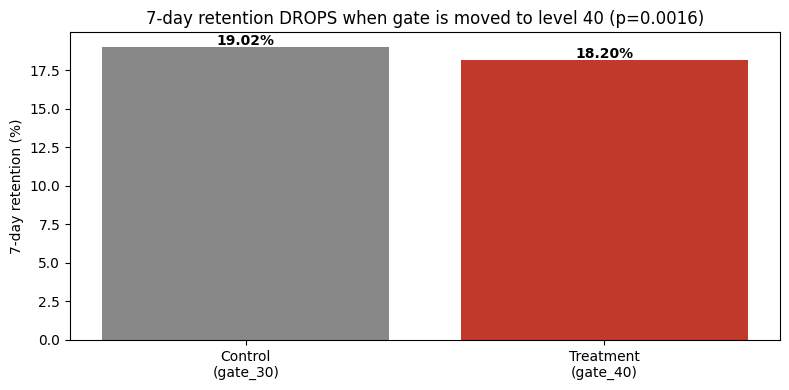

In [9]:
fig, ax = plt.subplots()
rates = [control.retention_7.mean()*100, treatment.retention_7.mean()*100]
bars = ax.bar(['Control\n(gate_30)', 'Treatment\n(gate_40)'], rates, color=['#888888', '#c0392b'])
for b, r in zip(bars, rates):
    ax.text(b.get_x()+b.get_width()/2, r+0.1, f'{r:.2f}%', ha='center', fontweight='bold')
ax.set_ylabel('7-day retention (%)')
ax.set_title(f"7-day retention DROPS when gate is moved to level 40 "
             f"(p={primary['p_value']:.4f})")
plt.tight_layout()
plt.savefig('../reports/retention_7_comparison.png', dpi=140)
plt.show()


## 8. Decision

Per the pre-specified rule (ship only if primary metric improves significantly
with no guardrail violations):


In [10]:
ship = primary['significant_after_correction'] and primary['absolute_diff'] > 0
print("Primary metric significant?", primary['significant_after_correction'])
print("Direction:", "IMPROVED" if primary['absolute_diff'] > 0 else "REGRESSED")
print()
if not ship:
    print("DECISION: DO NOT SHIP — REVERT TO GATE AT LEVEL 30")
    print("7-day retention is significantly LOWER with the gate at level 40 "
          "(-4.3% relative). This is a real regression, not a null result.")


Primary metric significant? True
Direction: REGRESSED

DECISION: DO NOT SHIP — REVERT TO GATE AT LEVEL 30
7-day retention is significantly LOWER with the gate at level 40 (-4.3% relative). This is a real regression, not a null result.


## 9. Conclusion

Moving the gate from level 30 to level 40 **significantly reduces 7-day
retention** (18.20% vs. 19.02%, a -4.3% relative change, Holm-adjusted
p ≈ 0.0047). 1-day retention and engagement (game rounds played) did not
show significant guardrail violations, but that's irrelevant here — the
primary metric itself moved in the wrong direction and significantly so.

**Recommendation: keep the gate at level 30. Do not ship the level-40 placement.**

This matches the actual, widely-cited conclusion drawn from this real dataset:
placing progression gates earlier, somewhat counterintuitively, is associated
with better long-run retention in this game — likely because a later gate
means more players hit the wait/paywall moment while still in the early,
more churn-prone part of the funnel, with less accumulated investment in the
game to keep them coming back.
